# Clasificador de vectores de soporte
Luego de calcular un baseline, se aplica un entrenamiento y clasificación de un modelo sencillo como lo es el clasificador de vectores de soporte, que nos servirá de modelo exploratorio.

Ya en el análisis preliminar de los datos se observó cierta superposición entre las distintas clases en prácticamente todos los features, por lo que automáticamente no se podría usar este clasificador con hard-margin. Avanzamos entonces con el clasificador de vectores de soporte con soft-margin, teniendo en cuenta que en realidad usando la librería de scikit-learn, el código no cambia.

In [2]:
import pandas as pd

## Tratamiento de datos

In [3]:
# Tratamiento de los datos
df = pd.read_csv('../dataset/star_classification.csv')
anomalias = df[(df['u'] == -9999) | (df['g'] == -9999) | (df['z'] == -9999)]

df = df[(df['u'] != -9999) & (df['g'] != -9999) & (df['z'] != -9999)]

In [4]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

train_idx, test_idx = next(gss.split(df, groups=df['obj_ID']))

train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]

features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

X_train = train_df[features]
X_test = test_df[features]

y_train = train_df['class']
y_test = test_df['class']

In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Entrenamiento SVC

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [7]:
# Probamos primero con un hiperparámtro C de ejemplo y kernel linear
svm_linear = SVC(C=10, kernel='linear')
svm_linear.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Test

Text(0.5, 1.0, 'Matriz de confusión SVC Linear, C=10')

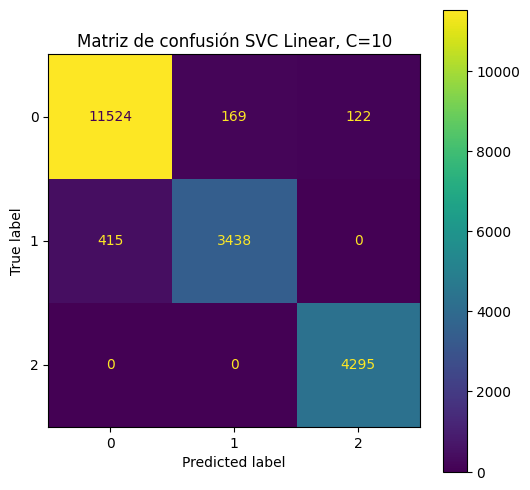

In [8]:
y_pred = svm_linear.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

disp_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=svm_linear.classes_
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.grid = False
disp_cm.plot(ax=ax)
ax.set_title("Matriz de confusión SVC Linear, C=10")

In [9]:
from sklearn.metrics import accuracy_score, recall_score, f1_score
from sklearn.metrics import classification_report

print("Métricas de la clasificación")
print(classification_report(y_test, y_pred))
# print(f"Precisión: {accuracy_score(y_test, y_pred):.4f}")
# print(f"Recall: {recall_score(y_test, y_pred, average='weighted'):.4f}")
# print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")

Métricas de la clasificación
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     11815
           1       0.95      0.89      0.92      3853
           2       0.97      1.00      0.99      4295

    accuracy                           0.96     19963
   macro avg       0.96      0.96      0.96     19963
weighted avg       0.96      0.96      0.96     19963



# Support Vector Machine
Como probablemente la mejor separación entre clases no sea lineal, se procede con modificar el kernel del modelo. El espacio es multidimensional por la cantidad de features involucrados, por lo cual resulta imposible una visualización de ello, para poder definir un kernel apropiado, entonces directamente se decide explorar múltiples hiperparámetros de manera análitica para encontrar los que mejor ajusten el modelo.

## Búsqueda de Hiperparámetros
Se aplica una búsqueda Bayesiana de hiperparámetros usando Optuna.

In [10]:
import optuna
from sklearn.model_selection import cross_val_score

Luego de algunos intentos, se notó que evaluar todo el dataset para la optimización de parámetros tomaría demasiado tiempo, y ya que esto se trata de una prueba de concepto del modelo mejor primero obtener algo sencillo para validar.

Por ello, se toman "aleatoriamente" una parte del dataset para esto.

In [11]:
from sklearn.utils import resample

n_samples = 20000

X_train_sub, y_train_sub = resample(
    X_train_scaled,
    y_train,
    n_samples=n_samples,
    replace=False,
    random_state=42,
    stratify=y_train
)

In [12]:
def objective(trial):
    # Definir el espacio de búsqueda para los hiperparámetros
    C = trial.suggest_float('C', 1e-4, 1e4, log=True)
    kernel = trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid'])
    # C = trial.suggest_float('C', 1, 1e4, log=True)
    # kernel = trial.suggest_categorical('kernel', ['linear','rbf'])

    # Algunos hiperparámetros dependen del kernel elegido
    if kernel in ['rbf', 'poly', 'sigmoid']:
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    else:
        gamma = 'scale' # Valor por defecto para kernel lineal

    degree = trial.suggest_int('degree', 2, 5) if kernel == 'poly' else 3

    # Instanciar el modelo con los hiperparámetros sugeridos con la prueba actual
    clf = SVC(
        C=C, 
        kernel=kernel,
        gamma=gamma,
        degree=degree,
        random_state=42
    )

    # Evaluar el modelo, usando validación cruzada
    # scores = cross_val_score(clf, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1, verbose=3)
    scores = cross_val_score(clf, X_train_sub, y_train_sub, cv=5, scoring='accuracy', n_jobs=-1, verbose=3)

    # Devolver la métrica a optimizar
    return scores.mean()

In [13]:
# Dirección: maximizar la métrica elegida (accuracy)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True, timeout=3600)

print("Mejores hiperparámetros encontrados:", study.best_params)
print("Mejor puntuación de validación cruzada:", study.best_value)

[I 2026-04-25 19:22:48,007] A new study created in memory with name: no-name-afd8d6d4-1360-4f59-b9d7-db41f1b06f12


  0%|          | 0/20 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   11.5s remaining:   17.4s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   11.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[I 2026-04-25 19:23:00,085] Trial 0 finished with value: 0.96785 and parameters: {'C': 539.4837148732233, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 0 with value: 0.96785.


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    6.9s remaining:   10.4s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    7.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[I 2026-04-25 19:23:07,452] Trial 1 finished with value: 0.9529500000000001 and parameters: {'C': 0.6717661262189495, 'kernel': 'linear'}. Best is trial 0 with value: 0.96785.


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   11.1s remaining:   16.7s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   11.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[I 2026-04-25 19:23:19,142] Trial 2 finished with value: 0.9212999999999999 and parameters: {'C': 0.1162225196212472, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.96785.


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    9.5s remaining:   14.2s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   12.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[I 2026-04-25 19:23:31,536] Trial 3 finished with value: 0.6524000000000001 and parameters: {'C': 0.0007886815030936759, 'kernel': 'poly', 'gamma': 'scale', 'degree': 5}. Best is trial 0 with value: 0.96785.


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   10.2s remaining:   15.3s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   10.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[I 2026-04-25 19:23:42,349] Trial 4 finished with value: 0.9667 and parameters: {'C': 1055.2117831792812, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 0 with value: 0.96785.


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   14.2s remaining:   21.4s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   14.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[I 2026-04-25 19:23:57,486] Trial 5 finished with value: 0.59515 and parameters: {'C': 0.00037986971619212835, 'kernel': 'sigmoid', 'gamma': 'scale'}. Best is trial 0 with value: 0.96785.


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   32.5s remaining:   48.8s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   36.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[I 2026-04-25 19:24:34,637] Trial 6 finished with value: 0.9625 and parameters: {'C': 7005.4761670598455, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.96785.


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   10.8s remaining:   16.2s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   11.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[I 2026-04-25 19:24:46,045] Trial 7 finished with value: 0.64635 and parameters: {'C': 0.0010520651247757436, 'kernel': 'poly', 'gamma': 'scale', 'degree': 2}. Best is trial 0 with value: 0.96785.


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    6.5s remaining:    9.7s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    6.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[I 2026-04-25 19:24:52,996] Trial 8 finished with value: 0.6988 and parameters: {'C': 5752.366650859272, 'kernel': 'sigmoid', 'gamma': 'auto'}. Best is trial 0 with value: 0.96785.


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    6.1s remaining:    9.2s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    6.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[I 2026-04-25 19:24:59,621] Trial 9 finished with value: 0.69885 and parameters: {'C': 1306.0989552179262, 'kernel': 'sigmoid', 'gamma': 'auto'}. Best is trial 0 with value: 0.96785.


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    7.8s remaining:   11.7s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    8.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[I 2026-04-25 19:25:08,110] Trial 10 finished with value: 0.96265 and parameters: {'C': 26.610051738914223, 'kernel': 'linear'}. Best is trial 0 with value: 0.96785.


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    4.0s remaining:    6.1s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    4.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[I 2026-04-25 19:25:12,565] Trial 11 finished with value: 0.968 and parameters: {'C': 89.06833618412821, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 11 with value: 0.968.


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    3.4s remaining:    5.1s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    3.6s finished


[I 2026-04-25 19:25:16,376] Trial 12 finished with value: 0.9674500000000001 and parameters: {'C': 40.094245109675036, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 11 with value: 0.968.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    3.5s remaining:    5.3s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    3.6s finished


[I 2026-04-25 19:25:20,237] Trial 13 finished with value: 0.9675 and parameters: {'C': 48.75696522701159, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 11 with value: 0.968.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    3.5s remaining:    5.3s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    3.5s finished


[I 2026-04-25 19:25:23,995] Trial 14 finished with value: 0.96065 and parameters: {'C': 4.205790826464995, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 11 with value: 0.968.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    5.0s remaining:    7.6s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.2s finished


[I 2026-04-25 19:25:29,391] Trial 15 finished with value: 0.9680000000000002 and parameters: {'C': 200.6837392760919, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 15 with value: 0.9680000000000002.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    7.5s remaining:   11.2s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    7.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[I 2026-04-25 19:25:37,403] Trial 16 finished with value: 0.91485 and parameters: {'C': 0.08176634532600023, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 15 with value: 0.9680000000000002.


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   19.5s remaining:   29.4s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   21.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[I 2026-04-25 19:25:59,120] Trial 17 finished with value: 0.9090499999999999 and parameters: {'C': 4.920464093466571, 'kernel': 'poly', 'gamma': 'auto', 'degree': 5}. Best is trial 15 with value: 0.9680000000000002.


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   13.6s remaining:   20.4s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   14.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[I 2026-04-25 19:26:14,084] Trial 18 finished with value: 0.96295 and parameters: {'C': 95.53535301017894, 'kernel': 'linear'}. Best is trial 15 with value: 0.9680000000000002.


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    5.1s remaining:    7.7s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.2s finished


[I 2026-04-25 19:26:19,525] Trial 19 finished with value: 0.9681 and parameters: {'C': 242.30810286039164, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 19 with value: 0.9681.
Mejores hiperparámetros encontrados: {'C': 242.30810286039164, 'kernel': 'rbf', 'gamma': 'auto'}
Mejor puntuación de validación cruzada: 0.9681


In [ ]:
# Entrenar un nuevo modelo con los mejores hiperparámetros encontrados
# Mejores hiperparámetros sin redshift: {'C': 1227.749418589842, 'kernel': 'rbf', 'gamma': 'auto'}
# Mejores hiperparámetros con redshift: {'C': 1393.569486, 'kernel': 'rbf', 'gamma': 'auto'}

best_svm = SVC(**study.best_params, random_state=42) # Usar este si se ejecutó la optimización
# best_svm = SVC(C=1227.749418589842, kernel='rbf', gamma='auto', random_state=42) # Ejecutar este para usar los parámetros hardcodeados
best_svm.fit(X_train_scaled, y_train)

# Evaluar en test con este nuevo modelo
y_pred = best_svm.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

Métricas de la clasificación
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11815
           1       0.97      0.93      0.95      3853
           2       0.97      1.00      0.99      4295

    accuracy                           0.97     19963
   macro avg       0.97      0.97      0.97     19963
weighted avg       0.97      0.97      0.97     19963



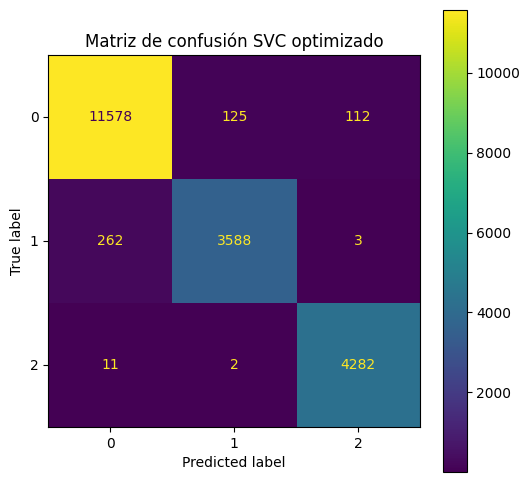

In [15]:
disp_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_svm.classes_
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.grid = False
disp_cm.plot(ax=ax)
ax.set_title("Matriz de confusión SVC optimizado")

print("Métricas de la clasificación")
print(classification_report(y_test, y_pred))

In [16]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))

0.9742022742072834


In [17]:
print(classification_report(y_test, y_pred, digits=16))

                  precision    recall  f1-score   support

               0  0.9769639692852924 0.9799407532797292 0.9784500971858362     11815
               1  0.9658142664872140 0.9312224240851285 0.9482029598308668      3853
               2  0.9738458039572436 0.9969732246798603 0.9852738150023009      4295

        accuracy                      0.9742022742072834     19963
       macro avg  0.9722080132432501 0.9693788006815726 0.9706422906730013     19963
    weighted avg  0.9741411307858200 0.9742022742072834 0.9740802954422615     19963

